### ECG200 
In this data set, each series traces the electrical activity recorded during one heartbeat. The two classes are a normal heartbeat versus a myocardial infarction event (heart attack due to prolonged cardiac ischemia).
http://www.timeseriesclassification.com/description.php?Dataset=ECG200

In [1]:

import pandas as pd
import numpy as np

# Load the ECG200 dataset from the UCR archive
ECG200_train = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TRAIN.tsv', header=None, sep='\t')
#ECG200_train = ECG200_train.iloc[:50]
print(ECG200_train.shape)

ECG200_test = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TEST.tsv', header=None, sep='\t')
#ECG200_test = ECG200_train.iloc[:50]
print(ECG200_test.shape)

# Here we prepare the data for the model
X_train = ECG200_train.iloc[:, 1:].values
Y_train = ECG200_train[0].values
X_test = ECG200_test.iloc[:, 1:].values
Y_test = ECG200_test[0].values

(100, 97)
(100, 97)


### `TS_Step_Tree_Train` Model


In [2]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import roc_auc_score

class Node:
    def __init__(self, witness, threshold, steps, class_distribution):
        self.witness = witness #stands for witness time series
        self.threshold = threshold
        self.steps = steps
        self.class_distribution = class_distribution
        self.TrueChild = None
        self.FalseChild = None
#Function for calculating the loss using Gini impurity
def Gini(group1, group2):
    _, counts1 = np.unique(group1, return_counts=True)
    _, counts2 = np.unique(group2, return_counts=True)
    gini1 = 1 - sum((count / len(group1)) ** 2 for count in counts1)
    gini2 = 1 - sum((count / len(group2)) ** 2 for count in counts2)
    return gini1 + gini2


#Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs)
    
    # Compute the information gain
    entropy_before = entropy(group1 + group2)
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / (len(group1) + len(group2))
    return entropy_before - entropy_after

# Main function for training the tree
def TS_Step_Tree_Train(X, Y, maxstep, stepsize, maxd, mins, exclusive_step=True):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))
    
    def Compute_Distance_Matrix(X):
        distance_matrix = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            for j in range(i, len(X)):
                distance = fastdtw(X[i].reshape(-1, 1), X[j].reshape(-1, 1), dist=euclidean)[0]
                distance_matrix[i, j] = distance
                distance_matrix[j, i] = distance
        return distance_matrix
    
    def Find_Witness(DM, Y):
        max_loss = 0
        witness, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                witness = X[i]
                wth = threshold

        return max_loss, witness, wth
    
    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        loss_values = [Loss([p[1] for p in pairs[:j]], [p[1] for p in pairs[j:]]) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j-1][0])/2

        return loss_values[j], threshold
    
    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        return Node(None, None, None, frequencies(Y))
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness, best_threshold, best_steps = None, None, None
        while i * stepsize <= real_maxstep:
            DM = Compute_Distance_Matrix(X[:, 0:i*stepsize])
            Ig, witness, threshold = Find_Witness(DM, Y)
            if bestIg < Ig:
                bestIg, best_witness, best_threshold, best_steps = Ig, witness[0:i*stepsize], threshold, i*stepsize
            i += 1
        
        if bestIg == 0:
            return Node(None, None, None, frequencies(Y))
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y))
            TrueIndexes = [i for i in range(len(X)) if fastdtw(best_witness.reshape(-1, 1), X[i, 0:best_steps].reshape(-1, 1), dist=euclidean)[0] <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            node.TrueChild = TS_Step_Tree_Train(X[TrueIndexes, best_steps+1:], Y[TrueIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(X[FalseIndexes, :], Y[FalseIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            else:
                node.FalseChild = TS_Step_Tree_Train(X[FalseIndexes, best_steps+1:], Y[FalseIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            return node

def predict(node, x):
    if node.witness is None:
        return max(node.class_distribution, key=node.class_distribution.get)
    distance = fastdtw(node.witness.reshape(-1, 1), x[0:node.steps].reshape(-1, 1), dist=euclidean)[0]
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[0:node.steps])
        else:
            return max(node.class_distribution, key=node.class_distribution.get)
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[0:node.steps])
        else:
            return max(node.class_distribution, key=node.class_distribution.get)

# Example usage
maxstep = 50
stepsize = 10
maxd = 7
mins = 2

# Train the model with exclusive_step=True
root_exclusive = TS_Step_Tree_Train(X_train, Y_train, maxstep, stepsize, maxd, mins, exclusive_step=True)

# Train the model with exclusive_step=False
root_non_exclusive = TS_Step_Tree_Train(X_train, Y_train, maxstep, stepsize, maxd, mins, exclusive_step=False)

# Generate predictions for the test data
probabilities_exclusive = []
for x in X_test:
    predicted_class = predict(root_exclusive, x)
    prob = 1 if predicted_class == 1 else 0
    probabilities_exclusive.append(prob)

# Convert -1 to 0 in Y_test
Y_test_binary = [1 if y == 1 else 0 for y in Y_test]

# Calculate the AUROC score for exclusive_step=True
auroc_exclusive = roc_auc_score(Y_test_binary, probabilities_exclusive)
print(f'AUROC Score (exclusive_step=True): {auroc_exclusive}')

# Generate predictions for the test data with exclusive_step=False
probabilities_non_exclusive = []
for x in X_test:
    predicted_class = predict(root_non_exclusive, x)
    prob = 1 if predicted_class == 1 else 0
    probabilities_non_exclusive.append(prob)

# Calculate the AUROC score for exclusive_step=False
auroc_non_exclusive = roc_auc_score(Y_test_binary, probabilities_non_exclusive)
print(f'AUROC Score (exclusive_step=False): {auroc_non_exclusive}')

AUROC Score (exclusive_step=True): 0.6848958333333333
AUROC Score (exclusive_step=False): 0.7456597222222222


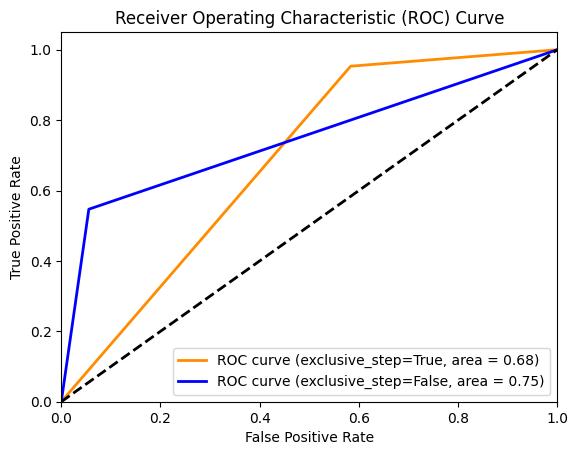

In [3]:
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt

# Calculate the false positive rate and true positive rate for exclusive_step=True
fpr_exclusive, tpr_exclusive, _ = roc_curve(Y_test, probabilities_exclusive)

# Calculate the false positive rate and true positive rate for exclusive_step=False
fpr_non_exclusive, tpr_non_exclusive, _ = roc_curve(Y_test, probabilities_non_exclusive)

# Plot the ROC curves
plt.figure()
plt.plot(fpr_exclusive, tpr_exclusive, color='darkorange', lw=2, label=f'ROC curve (exclusive_step=True, area = {auroc_exclusive:.2f})')
plt.plot(fpr_non_exclusive, tpr_non_exclusive, color='blue', lw=2, label=f'ROC curve (exclusive_step=False, area = {auroc_non_exclusive:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [4]:
from sklearn.metrics import classification_report

# Convert probabilities to binary predictions for exclusive_step=True
threshold = 0.5
predictions_exclusive = [1 if prob >= threshold else -1 for prob in probabilities_exclusive]

# Generate the classification report for exclusive_step=True
report_exclusive = classification_report(Y_test, predictions_exclusive, target_names=['Class -1', 'Class 1'])
print("Classification Report (exclusive_step=True):")
print(report_exclusive)

# Convert probabilities to binary predictions for exclusive_step=False
predictions_non_exclusive = [1 if prob >= threshold else -1 for prob in probabilities_non_exclusive]

# Generate the classification report for exclusive_step=False
report_non_exclusive = classification_report(Y_test, predictions_non_exclusive, target_names=['Class -1', 'Class 1'])
print("Classification Report (exclusive_step=False):")
print(report_non_exclusive)

Classification Report (exclusive_step=True):
              precision    recall  f1-score   support

    Class -1       0.83      0.42      0.56        36
     Class 1       0.74      0.95      0.84        64

    accuracy                           0.76       100
   macro avg       0.79      0.68      0.70       100
weighted avg       0.78      0.76      0.73       100

Classification Report (exclusive_step=False):
              precision    recall  f1-score   support

    Class -1       0.54      0.94      0.69        36
     Class 1       0.95      0.55      0.69        64

    accuracy                           0.69       100
   macro avg       0.74      0.75      0.69       100
weighted avg       0.80      0.69      0.69       100



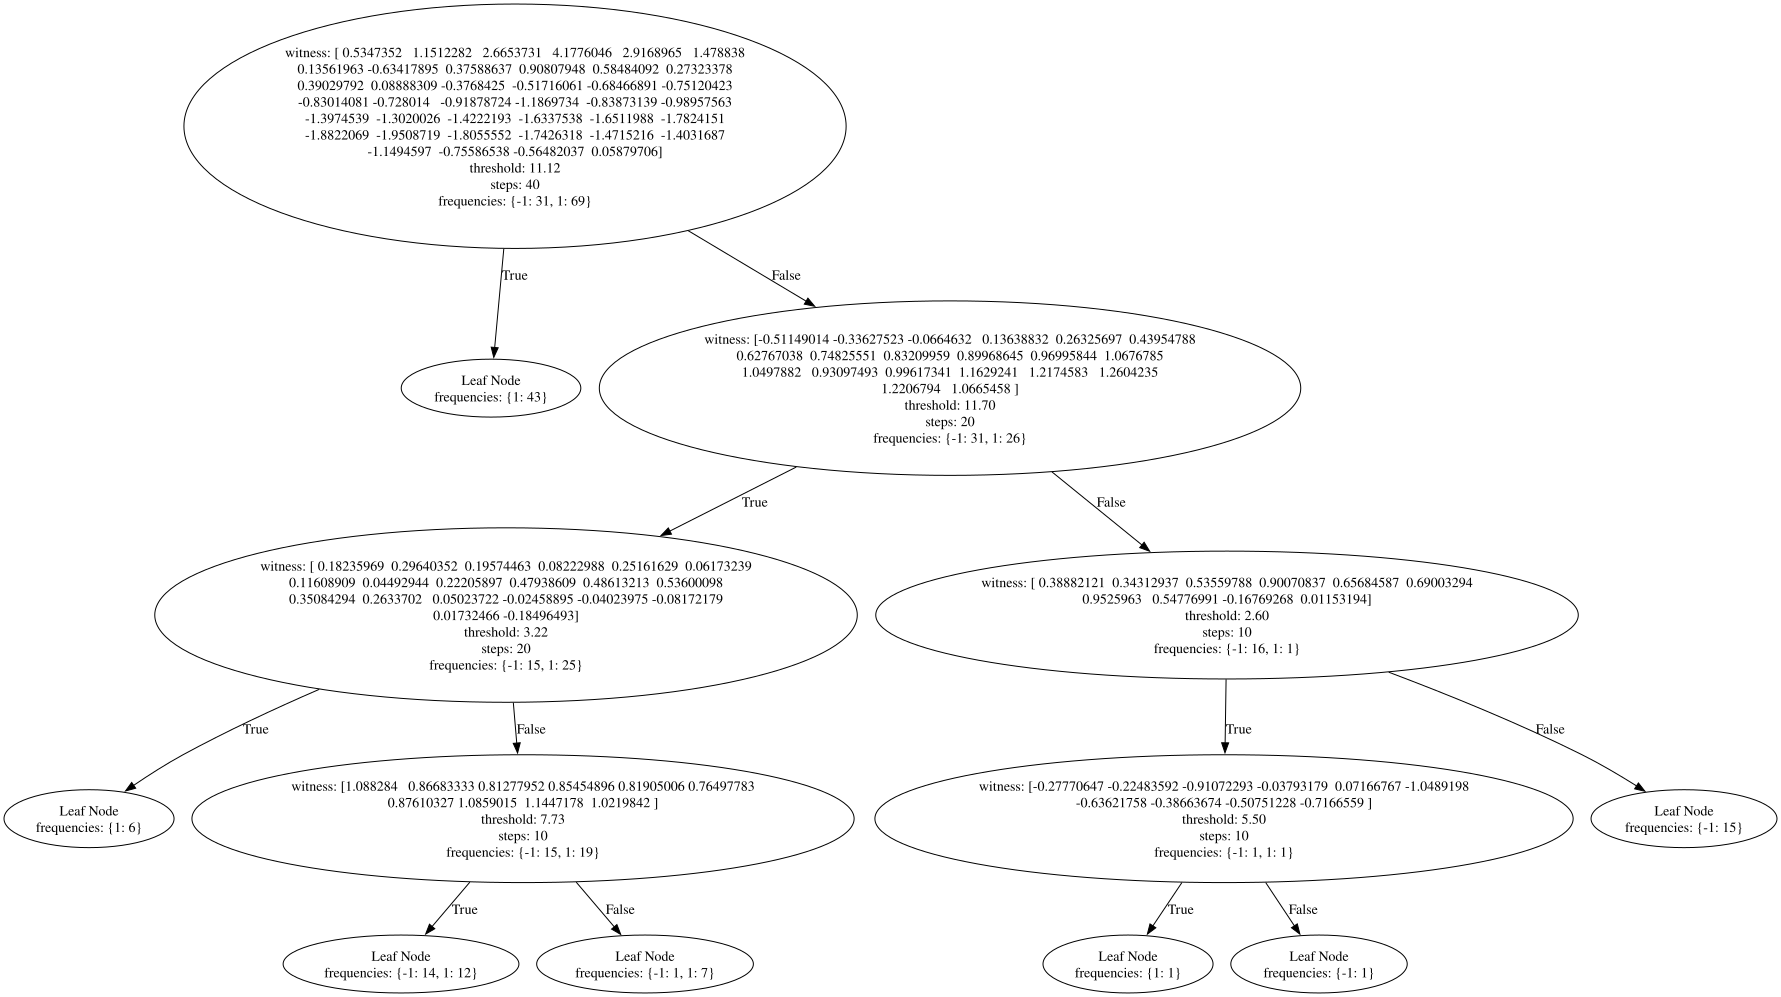

In [5]:
import graphviz

def visualize_step_tree(node, dot=None):
    if dot is None:
        dot = graphviz.Digraph()

    if node.TrueChild is None:
        node_label = 'Leaf Node\n' + ('No Data' if not node.class_distribution else 'frequencies: ' + str(node.class_distribution))
    else:
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\n'.format(node.witness, node.threshold, node.steps)
        node_label += 'No Data' if not node.class_distribution else 'frequencies: ' + str(node.class_distribution)

    dot.node(str(id(node)), label=node_label)

    if node.TrueChild is not None:
        dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
        visualize_step_tree(node.TrueChild, dot)

    if node.FalseChild is not None:
        dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
        visualize_step_tree(node.FalseChild, dot)

    return dot

dot = visualize_step_tree(root_non_exclusive)
dot.render('TS_Step_Tree_Non_Exclusive', format='png', cleanup=True)
dot

### New Dataset with multiple class (car)

Train size: 60, Test size: 60, Missing value: No, Number of classses: 4, Time series length: 577

https://www.aeon-toolkit.org/en/stable/examples/distances/distances.html

In [6]:
import numpy as np
import pandas as pd

# Load the car dataset from the UCR archive
car_train = pd.read_csv('UCRArchive_2018/Car/Car_TRAIN.tsv', header=None, sep='\t')
print(car_train.shape)

car_test = pd.read_csv('UCRArchive_2018/Car/Car_TEST.tsv', header=None, sep='\t')
print(car_test.shape)

# Here we prepare the data for the model
X_train = car_train.iloc[:, 1:].values
Y_train = car_train[0].values
X_test = car_test.iloc[:, 1:].values
Y_test = car_test[0].values

(60, 578)
(60, 578)


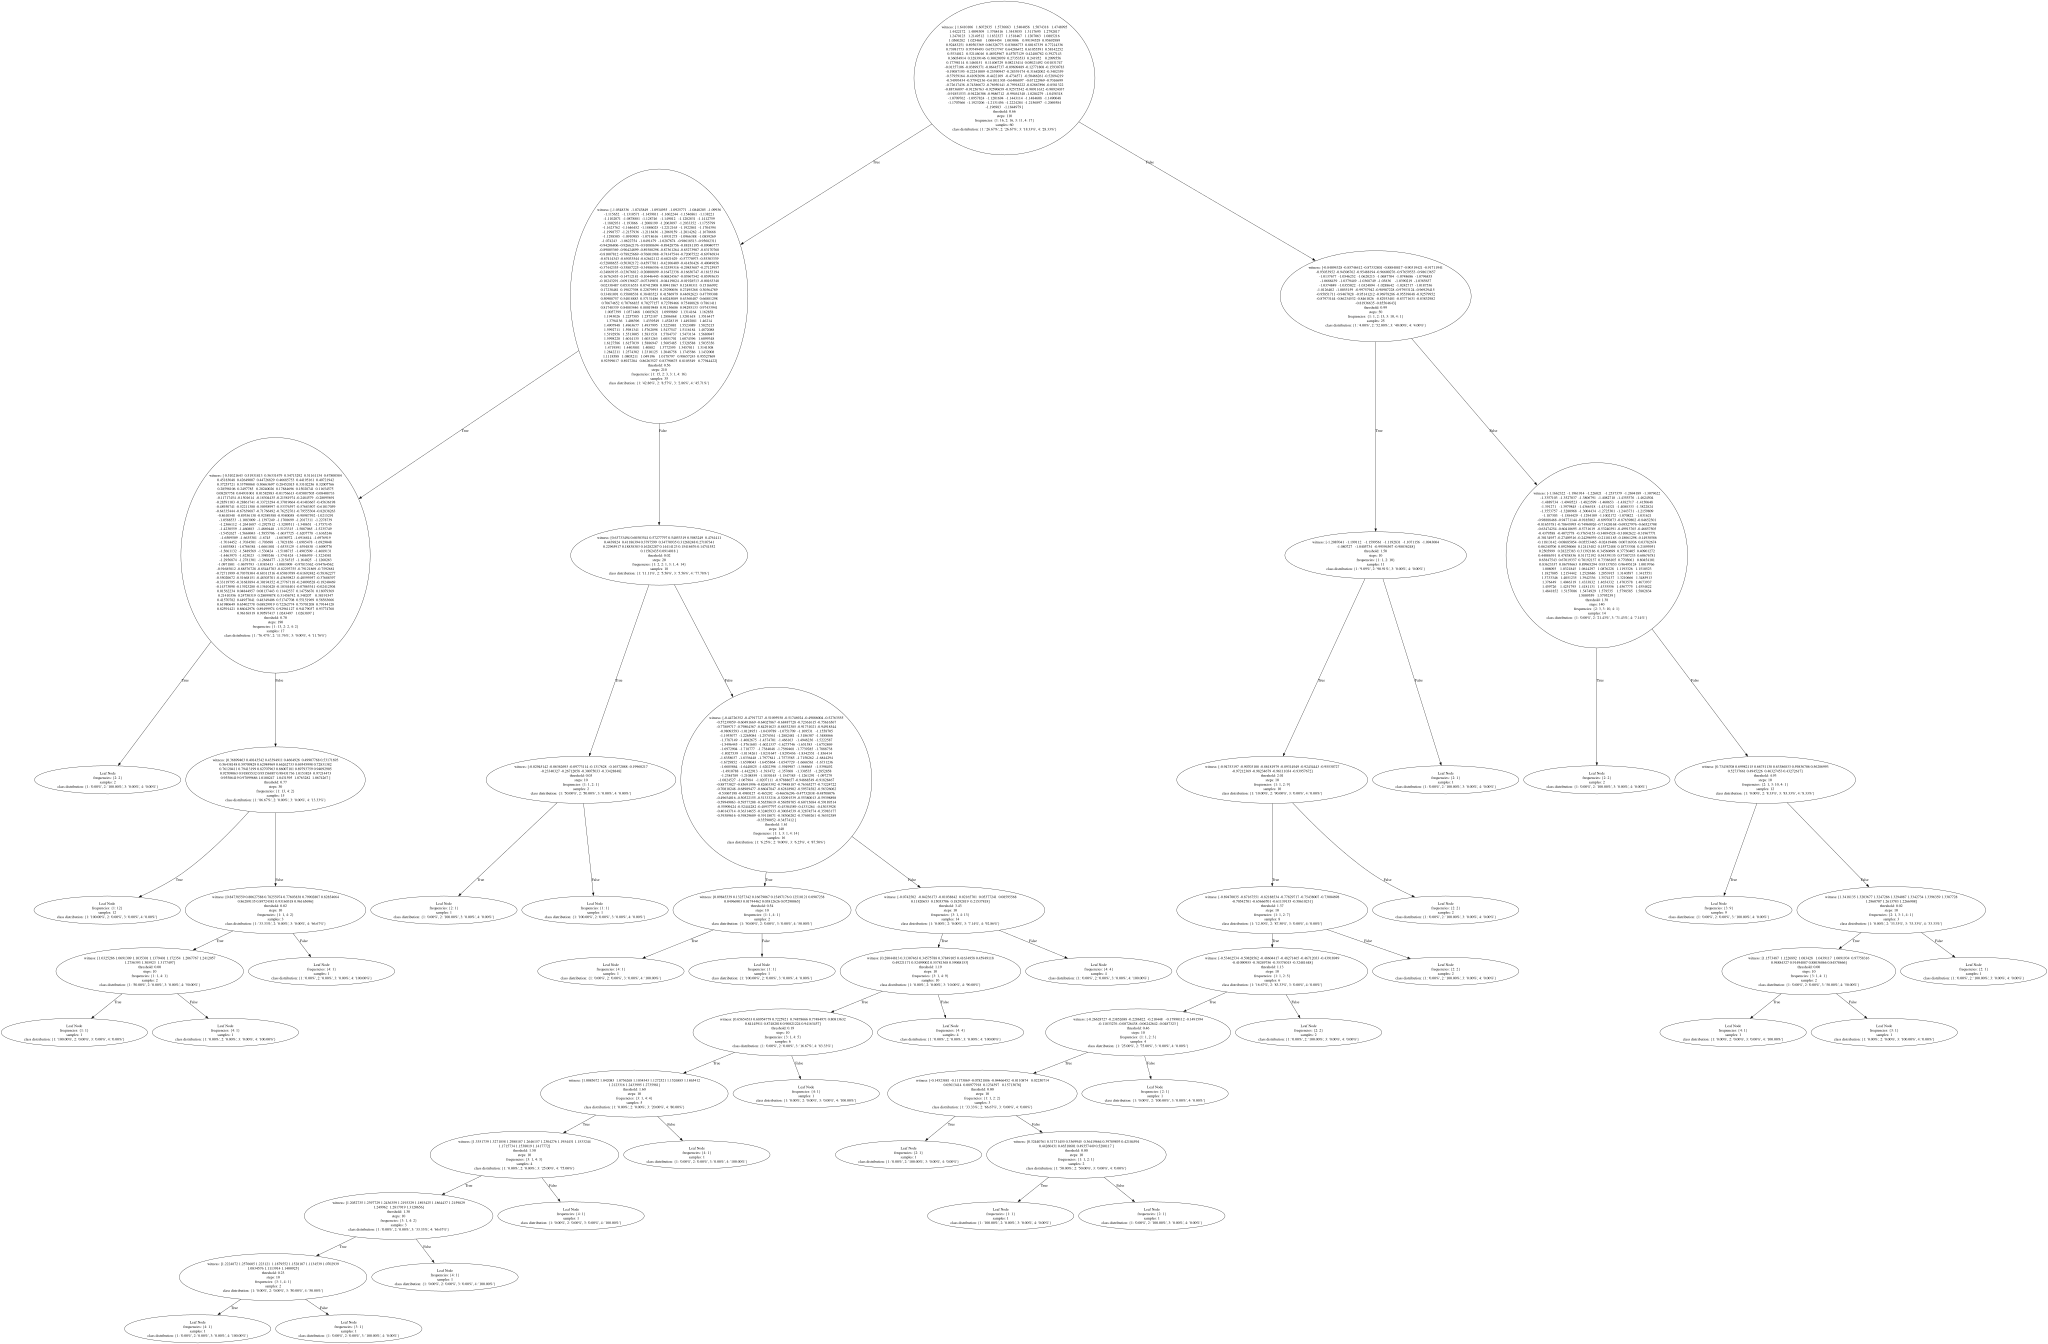

In [7]:
import numpy as np
from aeon.distances import dtw_distance, dtw_pairwise_distance, msm_distance
import graphviz

class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.calculate_probabilities(class_distribution, all_classes)
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
    
    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total for k in all_classes}
        return probabilities
    
#Function for calculating the loss using Gini impurity
def Gini(group1, group2):
    _, counts1 = np.unique(group1, return_counts=True)
    _, counts2 = np.unique(group2, return_counts=True)
    gini1 = 1 - sum((count / len(group1)) ** 2 for count in counts1)
    gini2 = 1 - sum((count / len(group2)) ** 2 for count in counts2)
    return gini1 + gini2


#Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs)
    
    # Compute the information gain
    entropy_before = entropy(group1 + group2)
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / (len(group1) + len(group2))
    return entropy_before - entropy_after

# Main training function for the tree model 
def TS_Step_Tree_Train(X, Y, maxstep, stepsize, maxd, mins, exclusive_step=True):
    all_classes = np.unique(Y)
    
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))
    
    def Compute_Distance_Matrix(X):
        return dtw_pairwise_distance(X)
    
    def Find_Witness(DM, Y):
        max_loss = 0
        witness, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                witness = X[i]
                wth = threshold

        return max_loss, witness, wth
    
    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        loss_values = [Loss([p[1] for p in pairs[:j]], [p[1] for p in pairs[j:]]) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j-1][0])/2

        return loss_values[j], threshold
    
    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        return Node(None, None, None, frequencies(Y), all_classes)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness, best_threshold, best_steps = None, None, None
        while i * stepsize <= real_maxstep:
            DM = Compute_Distance_Matrix(np.ascontiguousarray(X[:, 0:i*stepsize]))
            Ig, witness, threshold = Find_Witness(DM, Y)
            if bestIg < Ig:
                bestIg, best_witness, best_threshold, best_steps = Ig, witness[0:i*stepsize], threshold, i*stepsize
            i += 1
        
        if bestIg == 0:
            return Node(None, None, None, frequencies(Y), all_classes)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes)
            TrueIndexes = [i for i in range(len(X)) if dtw_distance(np.ascontiguousarray(best_witness), np.ascontiguousarray(X[i, 0:best_steps])) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            node.TrueChild = TS_Step_Tree_Train(np.ascontiguousarray(X[TrueIndexes, best_steps+1:]), Y[TrueIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(np.ascontiguousarray(X[FalseIndexes, :]), Y[FalseIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            else:
                node.FalseChild = TS_Step_Tree_Train(np.ascontiguousarray(X[FalseIndexes, best_steps+1:]), Y[FalseIndexes], maxstep, stepsize, maxd-1, mins, exclusive_step)
            return node

def predict(node, x):
    if node.witness is None:
        return node.probabilities
    distance = dtw_distance(np.ascontiguousarray(node.witness), np.ascontiguousarray(x[0:node.steps]))
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[0:node.steps])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[0:node.steps])
        else:
            return node.probabilities

# here we visualize the tree using graphviz package
def visualize_step_tree(node, all_classes, dot=None):
    if dot is None:
        dot = graphviz.Digraph()

    if node.TrueChild is None:
        if not node.class_distribution:
            node_label = 'Leaf Node\nNo Data'
        else:
            total = sum(node.raw_class_distribution.values())
            class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
            node_label = 'Leaf Node\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
                node.raw_class_distribution,
                node.samples,
                {k: f'{v:.2f}%' for k, v in class_distribution.items()}
            )
    else:
        total = sum(node.raw_class_distribution.values())
        class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
            node.witness, node.threshold, node.steps,
            node.raw_class_distribution,
            node.samples,
            {k: f'{v:.2f}%' for k, v in class_distribution.items()}
        )

    dot.node(str(id(node)), label=node_label)

    if node.TrueChild is not None:
        dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
        visualize_step_tree(node.TrueChild, all_classes, dot)

    if node.FalseChild is not None:
        dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
        visualize_step_tree(node.FalseChild, all_classes, dot)

    return dot

# Example usage
maxstep = 250
stepsize = 10
maxd = 15
mins = 2

# Train the model
train_example = TS_Step_Tree_Train(X_train, Y_train, maxstep, stepsize, maxd, mins, exclusive_step=False)

# Visualize the tree
all_classes = np.unique(Y_train)
dot = visualize_step_tree(train_example, all_classes)
dot.render('TS_Step_Tree', format='png', cleanup=True)
dot

### ROC Curves

One-vs-Rest (OvR) Scheme
AUROC Score (OvR): 0.5532502049855561


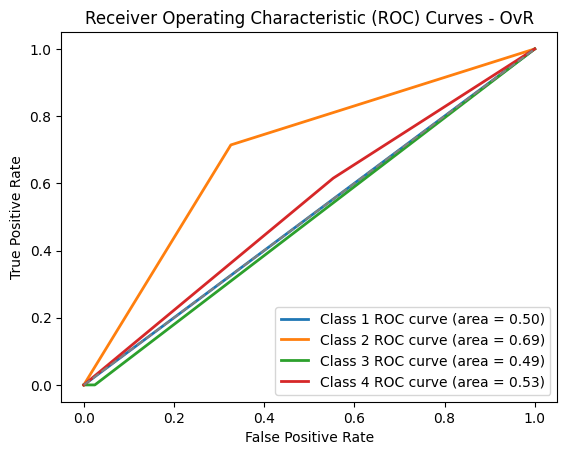

One-vs-One (OvO) Scheme
AUROC Score (OvO): 0.5532502049855561


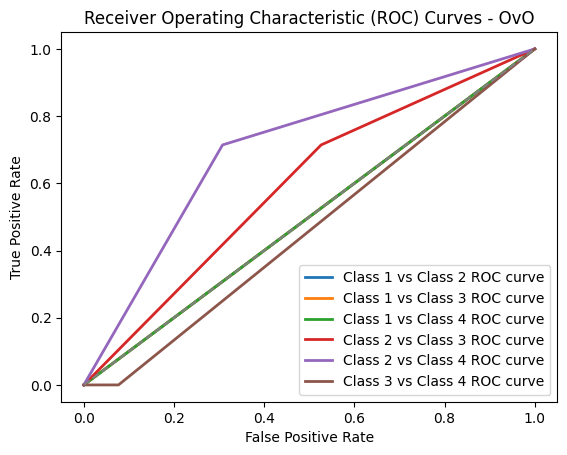

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# Binarize the labels for a one-vs-all (OvA) approach
all_classes = np.unique(Y_train)
Y_train_bin = label_binarize(Y_train, classes=all_classes)
Y_test_bin = label_binarize(Y_test, classes=all_classes)

# Generate predictions for the test data
probabilities_train_example = []
for x in X_test:
    prob = predict(train_example, x)
    probabilities_train_example.append([prob.get(cls, 0) for cls in all_classes])

# Convert probabilities to a 2D array
probabilities_train_example = np.array(probabilities_train_example)

# One-vs-Rest (OvR) Scheme
print("One-vs-Rest (OvR) Scheme")
if len(all_classes) > 2:
    auroc_ovr = roc_auc_score(Y_test_bin, probabilities_train_example, average='macro')
else:
    auroc_ovr = roc_auc_score(Y_test, probabilities_train_example[:, 1])
print(f'AUROC Score (OvR): {auroc_ovr}')

# Calculate the false positive rate and true positive rate for each class
fpr_ovr = dict()
tpr_ovr = dict()
if len(all_classes) > 2:
    for i in range(len(all_classes)):
        fpr_ovr[i], tpr_ovr[i], _ = roc_curve(Y_test_bin[:, i], probabilities_train_example[:, i])
else:
    fpr_ovr[0], tpr_ovr[0], _ = roc_curve(Y_test, probabilities_train_example[:, 1])

# Plot the ROC curves for OvR
plt.figure()
if len(all_classes) > 2:
    for i in range(len(all_classes)):
        plt.plot(fpr_ovr[i], tpr_ovr[i], lw=2, label=f'Class {all_classes[i]} ROC curve (area = {roc_auc_score(Y_test_bin[:, i], probabilities_train_example[:, i]):.2f})')
else:
    plt.plot(fpr_ovr[0], tpr_ovr[0], lw=2, label=f'ROC curve (area = {auroc_ovr:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves - OvR')
plt.legend(loc="lower right")
plt.show()

# One-vs-One (OvO) Scheme
if len(all_classes) > 2:
    print("One-vs-One (OvO) Scheme")
    auroc_ovo = roc_auc_score(Y_test_bin, probabilities_train_example, multi_class='ovo')
    print(f'AUROC Score (OvO): {auroc_ovo}')

    # Calculate the false positive rate and true positive rate for each pair of classes
    fpr_ovo = dict()
    tpr_ovo = dict()
    for (i, j) in combinations(range(len(all_classes)), 2):
        mask = np.logical_or(Y_test == all_classes[i], Y_test == all_classes[j])
        fpr_ovo[(i, j)], tpr_ovo[(i, j)], _ = roc_curve(Y_test_bin[mask][:, i], probabilities_train_example[mask][:, i])

    # Plot the ROC curves for OvO
    plt.figure()
    for (i, j) in combinations(range(len(all_classes)), 2):
        plt.plot(fpr_ovo[(i, j)], tpr_ovo[(i, j)], lw=2, label=f'Class {all_classes[i]} vs Class {all_classes[j]} ROC curve')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves - OvO')
    plt.legend(loc="lower right")
    plt.show()

### Classification Report

In [9]:
from sklearn.metrics import classification_report

# Convert probabilities to binary predictions for each class
threshold = 0.5
predictions_train_example = np.argmax(probabilities_train_example, axis=1) + 1  # Adding 1 to match class labels

# Generate the classification report for the multiclass dataset
report_train_example = classification_report(Y_test, predictions_train_example, target_names=[f'Class {cls}' for cls in all_classes])
print("Classification Report (multiclass):")
print(report_train_example)


Classification Report (multiclass):
              precision    recall  f1-score   support

     Class 1       0.00      0.00      0.00        14
     Class 2       0.40      0.71      0.51        14
     Class 3       0.00      0.00      0.00        19
     Class 4       0.24      0.62      0.34        13

    accuracy                           0.30        60
   macro avg       0.16      0.33      0.21        60
weighted avg       0.14      0.30      0.19        60



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Post-pruning the Tree

In [205]:
# Load the datasets from the UCR archive
#ECG200 (2 classes)
ecg200_train = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TRAIN.tsv', header=None, sep='\t')
print(f"ECG200 training data shape: {ECG200_train.shape}")
ecg200_test = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TEST.tsv', header=None, sep='\t')
print(f"ECG200 Test data shape: {ECG200_test.shape}")

# Strawberry (2 classes)
strawberry_train = pd.read_csv('UCRArchive_2018/Strawberry/Strawberry_TRAIN.tsv', header=None, sep='\t')
print(f"Strawberry training data shape: {strawberry_train.shape}")
strawberry_test = pd.read_csv('UCRArchive_2018/Strawberry/Strawberry_TEST.tsv', header=None, sep='\t')
print(f"Strawberry Test data shape: {strawberry_test.shape}")

# Wine (2 classes)
wine_train = pd.read_csv('UCRArchive_2018/Wine/Wine_TRAIN.tsv', header=None, sep='\t')
print(f"Wine training data shape: {wine_train.shape}")
wine_test = pd.read_csv('UCRArchive_2018/Wine/Wine_TEST.tsv', header=None, sep='\t')
print(f"Wine Test data shape: {wine_test.shape}")

# GunPoint (2 classes)
gunpoint_train = pd.read_csv('UCRArchive_2018/GunPoint/GunPoint_TRAIN.tsv', header=None, sep='\t')
print(f"GunPoint training data shape: {gunpoint_train.shape}")
gunpoint_test = pd.read_csv('UCRArchive_2018/GunPoint/GunPoint_TEST.tsv', header=None, sep='\t')
print(f"GunPoint Test data shape: {gunpoint_test.shape}")

# SmoothSubspace (3 classes)
smoothsubspace_train = pd.read_csv('UCRArchive_2018/SmoothSubspace/SmoothSubspace_TRAIN.tsv', header=None, sep='\t')
print(f"SmoothSubspace training data shape: {smoothsubspace_train.shape}")
smoothsubspace_test = pd.read_csv('UCRArchive_2018/SmoothSubspace/SmoothSubspace_TEST.tsv', header=None, sep='\t')
print(f"SmoothSubspace Test data shape: {smoothsubspace_test.shape}")

# MiddlePhalanxOutlineAgeGroup (3 classes)
middlephalanxoutlineagegroup_train = pd.read_csv('UCRArchive_2018/MiddlePhalanxOutlineAgeGroup/MiddlePhalanxOutlineAgeGroup_TRAIN.tsv', header=None, sep='\t')
print(f"MiddlePhalanxOutlineAgeGroup training data shape: {middlephalanxoutlineagegroup_train.shape}")
middlephalanxoutlineagegroup_test = pd.read_csv('UCRArchive_2018/MiddlePhalanxOutlineAgeGroup/MiddlePhalanxOutlineAgeGroup_TEST.tsv', header=None, sep='\t')
print(f"MiddlePhalanxOutlineAgeGroup Test data shape: {middlephalanxoutlineagegroup_test.shape}")

#CAR (4 classes)
car_train = pd.read_csv('UCRArchive_2018/Car/Car_TRAIN.tsv', header=None, sep='\t')
print(f"Car training data shape: {car_train.shape}")
car_test = pd.read_csv('UCRArchive_2018/Car/Car_TEST.tsv', header=None, sep='\t')
print(f"Car Test data shape: {car_test.shape}")

# WORMS (5 classes)
worms_train = pd.read_csv('UCRArchive_2018/Worms/Worms_TRAIN.tsv', header=None, sep='\t')
print(f"Worms training data shape: {worms_train.shape}")
worms_test = pd.read_csv('UCRArchive_2018/Worms/Worms_TEST.tsv', header=None, sep='\t')
print(f"Worms Test data shape: {worms_test.shape}")

# SyntheticControl (6 classes)
syntheticcontrol_train = pd.read_csv('UCRArchive_2018/SyntheticControl/SyntheticControl_TRAIN.tsv', header=None, sep='\t')
print(f"SyntheticControl training data shape: {syntheticcontrol_train.shape}")
syntheticcontrol_test = pd.read_csv('UCRArchive_2018/SyntheticControl/SyntheticControl_TEST.tsv', header=None, sep='\t')
print(f"SyntheticControl Test data shape: {syntheticcontrol_test.shape}")

# Fish (7 classes)
fish_train = pd.read_csv('UCRArchive_2018/Fish/Fish_TRAIN.tsv', header=None, sep='\t')
print(f"Fish training data shape: {fish_train.shape}")
fish_test = pd.read_csv('UCRArchive_2018/Fish/Fish_TEST.tsv', header=None, sep='\t')
print(f"Fish Test data shape: {fish_test.shape}")

# MedicalImages (10 classes)
medicalimages_train = pd.read_csv('UCRArchive_2018/MedicalImages/MedicalImages_TRAIN.tsv', header=None, sep='\t')
print(f"MedicalImages training data shape: {medicalimages_train.shape}")
medicalimages_test = pd.read_csv('UCRArchive_2018/MedicalImages/MedicalImages_TEST.tsv', header=None, sep='\t')
print(f"MedicalImages Test data shape: {medicalimages_test.shape}")

ECG200 training data shape: (100, 97)
ECG200 Test data shape: (100, 97)
Strawberry training data shape: (613, 236)
Strawberry Test data shape: (370, 236)
Wine training data shape: (57, 235)
Wine Test data shape: (54, 235)
GunPoint training data shape: (50, 151)
GunPoint Test data shape: (150, 151)
SmoothSubspace training data shape: (150, 16)
SmoothSubspace Test data shape: (150, 16)
MiddlePhalanxOutlineAgeGroup training data shape: (400, 81)
MiddlePhalanxOutlineAgeGroup Test data shape: (154, 81)
Car training data shape: (60, 578)
Car Test data shape: (60, 578)
Worms training data shape: (181, 901)
Worms Test data shape: (77, 901)
SyntheticControl training data shape: (300, 61)
SyntheticControl Test data shape: (300, 61)
Fish training data shape: (175, 464)
Fish Test data shape: (175, 464)
MedicalImages training data shape: (381, 100)
MedicalImages Test data shape: (760, 100)


In [206]:
import pandas as pd
from sklearn.model_selection import train_test_split

dataset = 'gunpoint'
dataset_train = eval(f'{dataset}_train')
dataset_test = eval(f'{dataset}_test')

# Separate features and target for training and test sets
X_train_full = dataset_train.iloc[:, 1:].values
Y_train_full = dataset_train.iloc[:, 0].values
X_test = dataset_test.iloc[:, 1:].values
Y_test = dataset_test.iloc[:, 0].values

# Split the training data into training and validation sets (15% for validation)
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X_train_full, Y_train_full, test_size=0.15, random_state=42, stratify=Y_train_full
)

# Check the sizes of each set
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_validation.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (42, 150)
Validation set shape: (8, 150)
Test set shape: (150, 150)


Accuracy on test set: 84.00%

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.76      0.83        76
           2       0.79      0.92      0.85        74

    accuracy                           0.84       150
   macro avg       0.85      0.84      0.84       150
weighted avg       0.85      0.84      0.84       150



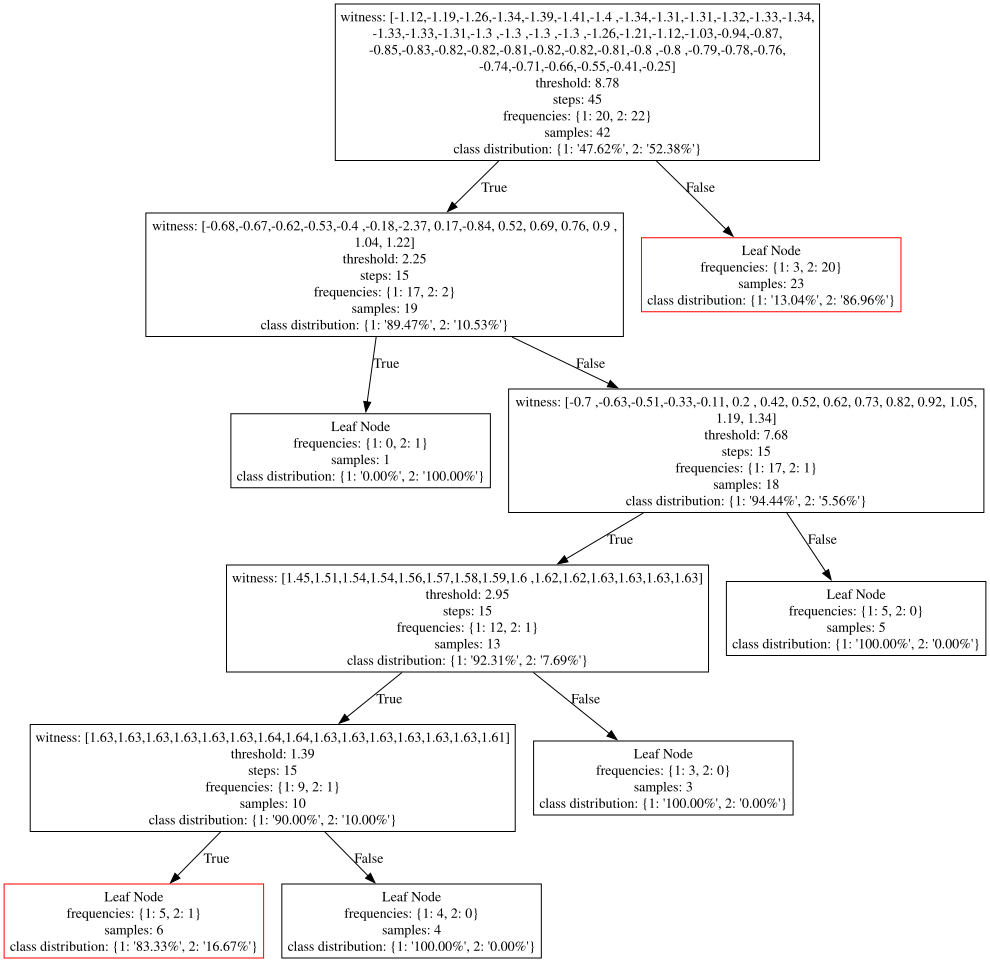

In [211]:
import numpy as np
from sklearn.metrics import classification_report
from aeon.distances import dtw_distance, dtw_pairwise_distance
import graphviz

# Define the Node class
class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total if total > 0 else 0 for k in all_classes}
        return probabilities

# Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children) * true_child.backed_up_error_rate +
                (false_child.validation_samples / total_children) * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model
def TS_Step_Tree_Train(X, Y, X_val, Y_val, maxstep, stepsize, maxd, mins, all_classes, exclusive_step=True, post_pruning=True):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    def Compute_Distance_Matrix(X):
        return dtw_pairwise_distance(X)

    def Find_Witness(DM, Y):
        max_loss = 0
        witness, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                witness = X[i]
                wth = threshold

        return max_loss, witness, wth

    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        if len(pairs) < 2:
            return 0, 0  # Cannot split
        loss_values = [Loss(
            np.array([p[1] for p in pairs[:j]]),
            np.array([p[1] for p in pairs[j:]])
        ) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

        return loss_values[j], threshold

    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        node = Node(None, None, None, frequencies(Y), all_classes)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness, best_threshold, best_steps = None, None, None
        while i * stepsize <= real_maxstep:
            DM = Compute_Distance_Matrix(np.ascontiguousarray(X[:, 0:i * stepsize]))
            Ig, witness, threshold = Find_Witness(DM, Y)
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness[0:i * stepsize]
                best_threshold = threshold
                best_steps = i * stepsize
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes)
            # Split the training data
            TrueIndexes = [i for i in range(len(X)) if dtw_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X[i, 0:best_steps])
            ) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [i for i in range(len(X_val)) if dtw_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X_val[i, 0:best_steps])
            ) <= best_threshold]
            FalseValIndexes = [i for i in range(len(X_val)) if i not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                np.ascontiguousarray(X[TrueIndexes, best_steps:]),
                Y[TrueIndexes],
                np.ascontiguousarray(X_val[TrueValIndexes, best_steps:]),
                Y_val[TrueValIndexes],
                maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
            )
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, :]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, :]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, best_steps + 1:]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, best_steps + 1:]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def predict(node, x):
    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance = dtw_distance(np.ascontiguousarray(node.witness), np.ascontiguousarray(x[0:node.steps]))
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:])
        else:
            return node.probabilities

# Visualize the tree using graphviz, highlighting pruned nodes in red
def visualize_step_tree(node, all_classes, dot=None):
    if dot is None:
        dot = graphviz.Digraph()

    if node.is_leaf:
        if not node.class_distribution:
            node_label = 'Leaf Node\nNo Data'
        else:
            total = sum(node.raw_class_distribution.values())
            class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
            node_label = 'Leaf Node\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
                node.raw_class_distribution,
                node.samples,
                {k: f'{v:.2f}%' for k, v in class_distribution.items()}
            )
    else:
        total = sum(node.raw_class_distribution.values())
        class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
        # Convert witness to string with limited length to avoid clutter
        witness_str = np.array2string(node.witness, precision=2, separator=',', suppress_small=True, max_line_width=80)
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
            witness_str,
            node.threshold,
            node.steps,
            node.raw_class_distribution,
            node.samples,
            {k: f'{v:.2f}%' for k, v in class_distribution.items()}
        )

    # Highlight pruned nodes in red
    if node.pruned:
        dot.node(str(id(node)), label=node_label, color='red', shape='box')
    else:
        dot.node(str(id(node)), label=node_label, shape='box')

    if not node.is_leaf:
        if node.TrueChild:
            dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
            visualize_step_tree(node.TrueChild, all_classes, dot)
        if node.FalseChild:
            dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
            visualize_step_tree(node.FalseChild, all_classes, dot)
    return dot

# Example usage
# Set your parameters
maxstep = 65
stepsize = 15
maxd = 15
mins = 2

# Combine all classes from training and validation sets
all_classes = np.unique(np.concatenate((Y_train, Y_validation)))

# Train the model with validation data and post-pruning option to be chosen
train_example = TS_Step_Tree_Train(
    X_train, Y_train, X_validation, Y_validation,
    maxstep, stepsize, maxd, mins,
    all_classes, exclusive_step=True, post_pruning=True
)

# Evaluate the tree on the test set
def evaluate_model(node, X_test, Y_test):
    correct = 0
    total = len(Y_test)
    y_true = []
    y_pred = []
    for x, y_t in zip(X_test, Y_test):
        probabilities = predict(node, x)
        y_p = max(probabilities, key=probabilities.get)
        y_true.append(y_t)
        y_pred.append(y_p)
        if y_p == y_t:
            correct += 1
    accuracy = correct / total
    print(f"Accuracy on test set: {accuracy * 100:.2f}%")
    # Generate classification report
    report = classification_report(y_true, y_pred, zero_division=1)
    print("\nClassification Report:")
    print(report)

evaluate_model(train_example, X_test, Y_test)

# Visualize the pruned tree
dot = visualize_step_tree(train_example, all_classes)
dot.render('TS_Step_Tree_Pruned', format='png', cleanup=True)
dot


### ROC Curves

One-vs-Rest (OvR) Scheme
AUROC Score (OvR): 0.8410384068278806


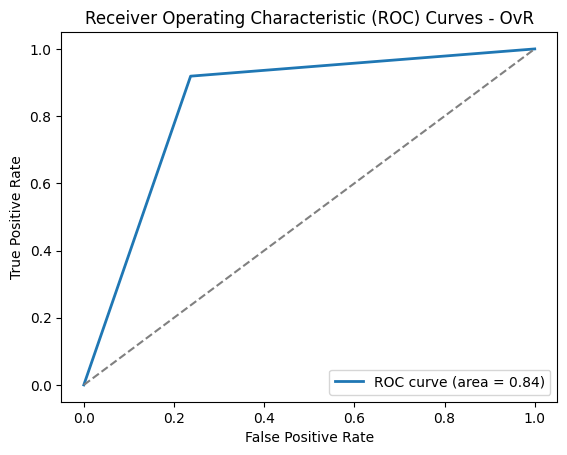

In [212]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# 'all_classes', 'train_example', 'X_test', 'Y_test', and 'predict' must be defined.

# Binarize the labels for a one-vs-all (OvR) approach
all_classes = np.unique(np.concatenate((Y_train, Y_validation, Y_test)))
Y_test_bin = label_binarize(Y_test, classes=all_classes)

# Generate predictions for the test data
probabilities_train_example = []
for x in X_test:
    prob = predict(train_example, x)
    # Ensure the probabilities are in the same order as 'all_classes'
    probabilities = [prob.get(cls, 0) for cls in all_classes]
    probabilities_train_example.append(probabilities)

# Convert probabilities to a 2D array
probabilities_train_example = np.array(probabilities_train_example)

# One-vs-Rest (OvR) Scheme
print("One-vs-Rest (OvR) Scheme")
if len(all_classes) > 2:
    # Calculate the AUROC score using 'ovr' for multiclass
    auroc_ovr = roc_auc_score(Y_test_bin, probabilities_train_example, average='macro', multi_class='ovr')
else:
    # For binary classification
    auroc_ovr = roc_auc_score(Y_test_bin.ravel(), probabilities_train_example[:, 1])
print(f'AUROC Score (OvR): {auroc_ovr}')

# Calculate the false positive rate and true positive rate for each class
fpr_ovr = dict()
tpr_ovr = dict()
roc_auc_ovr = dict()
if len(all_classes) > 2:
    for i in range(len(all_classes)):
        # For each class 'i', 'Y_test_bin[:, i]' has 1s for class 'i' and 0s otherwise
        # 'probabilities_train_example[:, i]' contains the probabilities for class 'i'
        fpr_ovr[i], tpr_ovr[i], _ = roc_curve(Y_test_bin[:, i], probabilities_train_example[:, i])
        roc_auc_ovr[i] = roc_auc_score(Y_test_bin[:, i], probabilities_train_example[:, i])
else:
    fpr_ovr[0], tpr_ovr[0], _ = roc_curve(Y_test_bin.ravel(), probabilities_train_example[:, 1])
    roc_auc_ovr[0] = auroc_ovr

# Plot the ROC curves for OvR
plt.figure()
if len(all_classes) > 2:
    for i in range(len(all_classes)):
        plt.plot(fpr_ovr[i], tpr_ovr[i], lw=2, label=f'Class {all_classes[i]} ROC curve (area = {roc_auc_ovr[i]:.2f})')
else:
    plt.plot(fpr_ovr[0], tpr_ovr[0], lw=2, label=f'ROC curve (area = {roc_auc_ovr[0]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves - OvR')
plt.legend(loc="lower right")
plt.show()

# One-vs-One (OvO) Scheme
if len(all_classes) > 2:
    print("One-vs-One (OvO) Scheme")
    auroc_ovo = roc_auc_score(Y_test_bin, probabilities_train_example, average='macro', multi_class='ovo')
    print(f'AUROC Score (OvO): {auroc_ovo}')

    # Calculate the false positive rate and true positive rate for each pair of classes
    fpr_ovo = dict()
    tpr_ovo = dict()
    roc_auc_ovo = dict()
    for (i, j) in combinations(range(len(all_classes)), 2):
        # Create a mask for the two classes
        mask = np.logical_or(Y_test == all_classes[i], Y_test == all_classes[j])
        Y_test_pair = Y_test[mask]
        if len(np.unique(Y_test_pair)) < 2:
            # Skip this pair since only one class is present
            continue
        # Map the labels to binary: 0 for class all_classes[i], 1 for class all_classes[j]
        Y_test_bin_pair = np.array([0 if y == all_classes[i] else 1 for y in Y_test_pair])
        probabilities_pair = probabilities_train_example[mask][:, [i, j]]
        # Use probabilities for the positive class (all_classes[j])
        y_score = probabilities_pair[:, 1]
        fpr, tpr, _ = roc_curve(Y_test_bin_pair, y_score)
        fpr_ovo[(i, j)] = fpr
        tpr_ovo[(i, j)] = tpr
        # Compute AUC score using probabilities for the positive class
        auc_score = roc_auc_score(Y_test_bin_pair, y_score)
        roc_auc_ovo[(i, j)] = auc_score

    # Plot the ROC curves for OvO
    plt.figure()
    for (i, j) in combinations(range(len(all_classes)), 2):
        if (i, j) not in fpr_ovo:
            # This pair was skipped due to only one class present
            continue
        auc_score = roc_auc_ovo[(i, j)]
        plt.plot(fpr_ovo[(i, j)], tpr_ovo[(i, j)], lw=2,
                 label=f'Class {all_classes[i]} vs Class {all_classes[j]} ROC curve (area = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves - OvO')
    plt.legend(loc="lower right")
    plt.show()


## FOREST

In [165]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from aeon.distances import dtw_distance, dtw_pairwise_distance
import graphviz
import random
from collections import Counter
import multiprocessing

# Define the Node class (same as before)
class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total if total > 0 else 0 for k in all_classes}
        return probabilities

# Function for calculating the loss using entropy (same as before)
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning (same as before)
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children) * true_child.backed_up_error_rate +
                (false_child.validation_samples / total_children) * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model (same as before)
def TS_Step_Tree_Train(X, Y, X_val, Y_val, maxstep, stepsize, maxd, mins, all_classes, exclusive_step=True, post_pruning=True):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    def Compute_Distance_Matrix(X):
        return dtw_pairwise_distance(X)

    def Find_Witness(DM, Y):
        max_loss = 0
        witness, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                witness = X[i]
                wth = threshold

        return max_loss, witness, wth

    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        if len(pairs) < 2:
            return 0, 0  # Cannot split
        loss_values = [Loss(
            np.array([p[1] for p in pairs[:j]]),
            np.array([p[1] for p in pairs[j:]])
        ) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

        return loss_values[j], threshold

    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        node = Node(None, None, None, frequencies(Y), all_classes)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness, best_threshold, best_steps = None, None, None
        while i * stepsize <= real_maxstep:
            DM = Compute_Distance_Matrix(np.ascontiguousarray(X[:, 0:i * stepsize]))
            Ig, witness, threshold = Find_Witness(DM, Y)
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness[0:i * stepsize]
                best_threshold = threshold
                best_steps = i * stepsize
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes)
            # Split the training data
            TrueIndexes = [i for i in range(len(X)) if dtw_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X[i, 0:best_steps])
            ) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [i for i in range(len(X_val)) if dtw_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X_val[i, 0:best_steps])
            ) <= best_threshold]
            FalseValIndexes = [i for i in range(len(X_val)) if i not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                np.ascontiguousarray(X[TrueIndexes, best_steps:]),
                Y[TrueIndexes],
                np.ascontiguousarray(X_val[TrueValIndexes, best_steps:]),
                Y_val[TrueValIndexes],
                maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
            )
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, :]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, :]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, best_steps + 1:]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, best_steps + 1:]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes, exclusive_step, post_pruning=False
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def predict(node, x):
    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance = dtw_distance(np.ascontiguousarray(node.witness), np.ascontiguousarray(x[0:node.steps]))
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:])
        else:
            return node.probabilities

# Implement the Random Forest
class RandomForest:
    def __init__(self, n_trees, maxstep, stepsize, maxd, mins, exclusive_step=True, post_pruning=True):
        self.n_trees = n_trees
        self.maxstep = maxstep
        self.stepsize = stepsize
        self.maxd = maxd
        self.mins = mins
        self.exclusive_step = exclusive_step
        self.post_pruning = post_pruning
        self.trees = []
        self.all_classes = None

    def fit(self, X, Y):
        self.all_classes = np.unique(Y)
        n_samples = X.shape[0]
        # Build each tree
        for i in range(self.n_trees):
            print(f"Training tree {i + 1}/{self.n_trees}")
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            oob_indices = [i for i in range(n_samples) if i not in indices]
            
            X_bootstrap = X[indices]
            Y_bootstrap = Y[indices]
            X_oob = X[oob_indices]
            Y_oob = Y[oob_indices]
            # Train the tree
            tree = TS_Step_Tree_Train(
                X_bootstrap, Y_bootstrap,
                X_oob, Y_oob,
                self.maxstep, self.stepsize, self.maxd, self.mins,
                self.all_classes,
                self.exclusive_step, self.post_pruning
            )
            self.trees.append(tree)

    def predict(self, x):
        # Aggregate predictions from all trees
        votes = []
        for tree in self.trees:
            probabilities = predict(tree, x)
            predicted_class = max(probabilities, key=probabilities.get)
            votes.append(predicted_class)
        # Majority voting
        vote_counts = Counter(votes)
        majority_class = vote_counts.most_common(1)[0][0]
        return majority_class

    def evaluate(self, X_test, Y_test):
        y_true, y_pred = [], []
        for x, y_t in zip(X_test, Y_test):
            y_p = self.predict(x)
            y_true.append(y_t)
            y_pred.append(y_p)
        print("\nRandom Forest Classification Report:")
        print(classification_report(y_true, y_pred, zero_division=1))

# Example usage

# we need X_train_full, Y_train_full, X_test, Y_test, for Random Forest, we'll use the entire training data.

# Set your parameters
n_trees = 20  
maxstep = 200
stepsize = 10
maxd = 15
mins = 2

# Initialize the Random Forest
rf = RandomForest(n_trees, maxstep, stepsize, maxd, mins, exclusive_step=False, post_pruning=True)

# Fit the Random Forest
rf.fit(X_train_full, Y_train_full)

# Evaluate the Random Forest on the test set
rf.evaluate(X_test, Y_test)


Training tree 1/20
Training tree 2/20
Training tree 3/20
Training tree 4/20
Training tree 5/20
Training tree 6/20
Training tree 7/20
Training tree 8/20
Training tree 9/20
Training tree 10/20
Training tree 11/20
Training tree 12/20
Training tree 13/20
Training tree 14/20
Training tree 15/20
Training tree 16/20
Training tree 17/20
Training tree 18/20
Training tree 19/20
Training tree 20/20

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.82      0.89        76
           2       0.84      0.99      0.91        74

    accuracy                           0.90       150
   macro avg       0.91      0.90      0.90       150
weighted avg       0.91      0.90      0.90       150



### Trying different distances from AEON library (Manual)

Accuracy on test set: 86.00%

Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.82      0.86        76
           2       0.83      0.91      0.86        74

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150



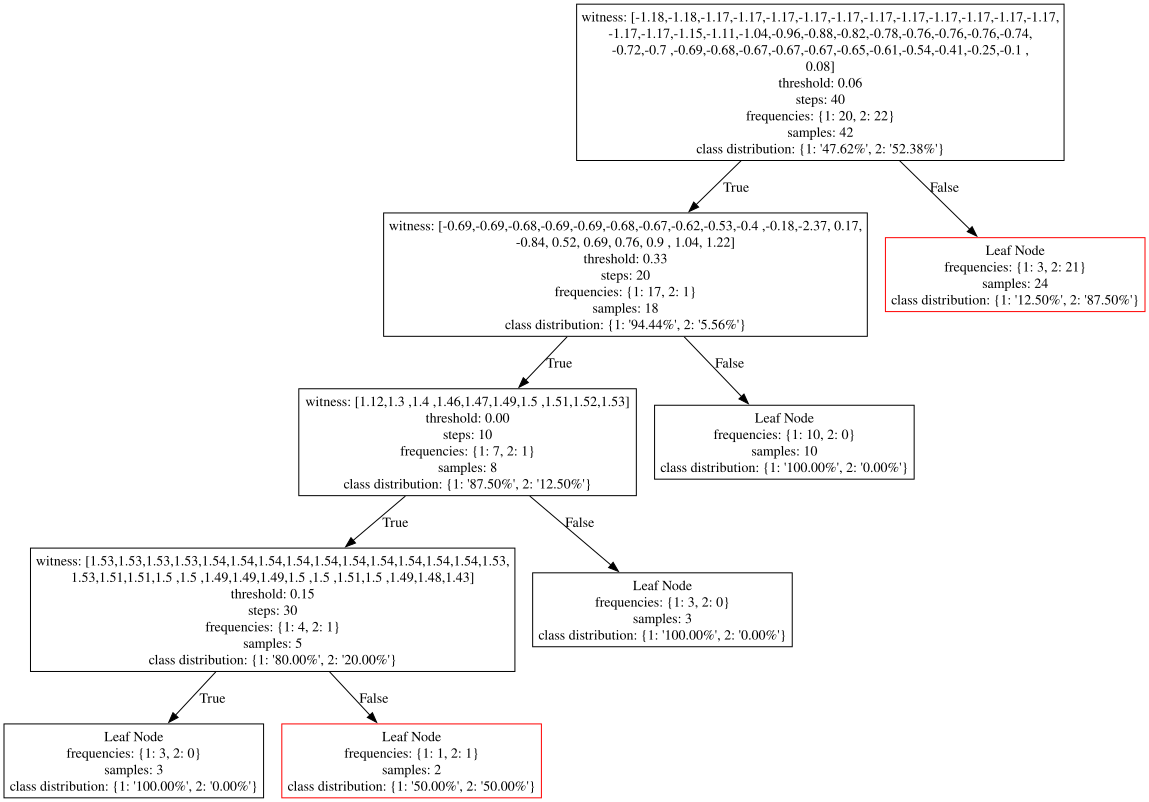

In [186]:
import numpy as np
from sklearn.metrics import classification_report
from aeon.distances import distance as aeon_distance
from aeon.distances import pairwise_distance as aeon_pairwise_distance
import graphviz

# Define the Node class (same as before)
class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total if total > 0 else 0 for k in all_classes}
        return probabilities

# Function for calculating the loss using entropy (same as before)
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning (same as before)
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        majority_class_count = node.validation_class_distribution.get(
            max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
        )
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children) * true_child.backed_up_error_rate +
                (false_child.validation_samples / total_children) * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model
def TS_Step_Tree_Train(X, Y, X_val, Y_val, maxstep, stepsize, maxd, mins, all_classes,
                       distance_metric='dtw', distance_params=None,
                       exclusive_step=True, post_pruning=True):
    if distance_params is None:
        distance_params = {}

    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    # Modify Compute_Distance_Matrix to use the specified distance function
    def Compute_Distance_Matrix(X_subset):
        return aeon_pairwise_distance(X_subset, metric=distance_metric, **distance_params)

    def Find_Witness(DM, Y, X_subset):
        max_loss = 0
        witness, wth = None, None

        for i in range(len(X_subset)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                witness = X_subset[i]
                wth = threshold

        return max_loss, witness, wth

    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        if len(pairs) < 2:
            return 0, 0  # Cannot split
        loss_values = [Loss(
            np.array([p[1] for p in pairs[:j]]),
            np.array([p[1] for p in pairs[j:]])
        ) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

        return loss_values[j], threshold

    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        node = Node(None, None, None, frequencies(Y), all_classes)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness, best_threshold, best_steps = None, None, None
        while i * stepsize <= real_maxstep:
            X_subset = np.ascontiguousarray(X[:, 0:i * stepsize])
            DM = Compute_Distance_Matrix(X_subset)
            Ig, witness, threshold = Find_Witness(DM, Y, X_subset)
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness
                best_threshold = threshold
                best_steps = i * stepsize
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes)
            # Split the training data
            TrueIndexes = [i for i in range(len(X)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X[i, 0:best_steps]),
                metric=distance_metric,
                **distance_params
            ) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [i for i in range(len(X_val)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X_val[i, 0:best_steps]),
                metric=distance_metric,
                **distance_params
            ) <= best_threshold]
            FalseValIndexes = [i for i in range(len(X_val)) if i not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                np.ascontiguousarray(X[TrueIndexes, best_steps:]),
                Y[TrueIndexes],
                np.ascontiguousarray(X_val[TrueValIndexes, best_steps:]),
                Y_val[TrueValIndexes],
                maxstep, stepsize, maxd - 1, mins, all_classes,
                distance_metric, distance_params, exclusive_step, post_pruning=False
            )
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, :]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, :]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_metric, distance_params, exclusive_step, post_pruning=False
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, best_steps + 1:]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, best_steps + 1:]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_metric, distance_params, exclusive_step, post_pruning=False
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

# The predict function needs to be updated to accept the distance function and parameters
def predict(node, x, distance_metric='dtw', distance_params=None):
    if distance_params is None:
        distance_params = {}

    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance = aeon_distance(
        np.ascontiguousarray(node.witness),
        np.ascontiguousarray(x[0:node.steps]),
        metric=distance_metric,
        **distance_params
    )
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:], distance_metric, distance_params)
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:], distance_metric, distance_params)
        else:
            return node.probabilities

# The visualize_step_tree function remains unchanged

# Example usage
# Set your parameters
maxstep = 200
stepsize = 10
maxd = 15
mins = 2

# Combine all classes from training and validation sets
all_classes = np.unique(np.concatenate((Y_train, Y_validation)))

# Choose the distance metric and parameters
distance_metric = 'lcss'  # Options: 'euclidean', 'dtw', 'ddtw', 'wdtw', etc.
distance_params = {'window': None, 'g': 5, 'epsilon':0.5}  # Additional parameters for the distance function like:
#{'window': 0.2 for dtw} or {'g': 0.5 for wdtw(weighted dynamic time wrapping)} or {'epsilon': 1.0 for lcss(longest common subsequence)} 
# or {'g': 0.0 for erp (edit distance with real penalty)} or {'c': 1.0 for msm(move-split-merge)}

# Train the model with validation data and post-pruning option
train_example = TS_Step_Tree_Train(
    X_train, Y_train, X_validation, Y_validation,
    maxstep, stepsize, maxd, mins,
    all_classes, distance_metric, distance_params,
    exclusive_step=True, post_pruning=True
)

# Evaluate the tree on the test set
def evaluate_model(node, X_test, Y_test, distance_metric='dtw', distance_params=None):
    if distance_params is None:
        distance_params = {}
    correct = 0
    total = len(Y_test)
    y_true = []
    y_pred = []
    for x, y_t in zip(X_test, Y_test):
        probabilities = predict(node, x, distance_metric, distance_params)
        y_p = max(probabilities, key=probabilities.get)
        y_true.append(y_t)
        y_pred.append(y_p)
        if y_p == y_t:
            correct += 1
    accuracy = correct / total
    print(f"Accuracy on test set: {accuracy * 100:.2f}%")
    # Generate classification report
    report = classification_report(y_true, y_pred, zero_division=1)
    print("\nClassification Report:")
    print(report)

evaluate_model(train_example, X_test, Y_test, distance_metric, distance_params)

# Visualize the pruned tree
dot = visualize_step_tree(train_example, all_classes)
dot.render('TS_Step_Tree_Pruned', format='png', cleanup=True)
dot


### New version with choosing the best distance functions from AEON library in each split

Error computing distances with metric ddtw and params {'window': None}: Time series must have at least 3 points.
Error computing distances with metric ddtw and params {'window': 0.1}: Time series must have at least 3 points.
Error computing distances with metric ddtw and params {'window': 0.2}: Time series must have at least 3 points.
Error computing distances with metric ddtw and params {'window': 0.5}: Time series must have at least 3 points.
Error computing distances with metric ddtw and params {'window': 1.0}: Time series must have at least 3 points.
Error computing distances with metric wddtw and params {'g': 0.0}: Time series must have at least 3 points.
Error computing distances with metric wddtw and params {'g': 0.5}: Time series must have at least 3 points.
Error computing distances with metric wddtw and params {'g': 1.0}: Time series must have at least 3 points.
Error computing distances with metric ddtw and params {'window': None}: Time series must have at least 3 points.
Er

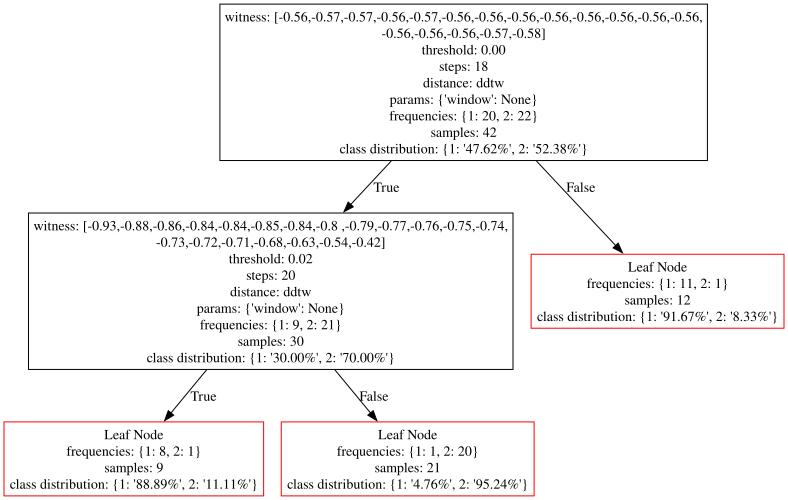

In [220]:
import numpy as np
from sklearn.metrics import classification_report
from aeon.distances import distance as aeon_distance
from aeon.distances import pairwise_distance as aeon_pairwise_distance
import graphviz

# Define the Node class
class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes,
                 distance_metric=None, distance_params=None):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.distance_metric = distance_metric  # Store the selected distance metric
        self.distance_params = distance_params  # Store the selected distance parameters
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total if total > 0 else 0 for k in all_classes}
        return probabilities

# Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children) * true_child.backed_up_error_rate +
                (false_child.validation_samples / total_children) * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model
def TS_Step_Tree_Train(X, Y, X_val, Y_val, maxstep, stepsize, maxd, mins, all_classes,
                       distance_functions,
                       exclusive_step=True, post_pruning=True):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        node = Node(None, None, None, frequencies(Y), all_classes)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness = None
        best_threshold = None
        best_steps = None
        best_distance_metric = None
        best_distance_params = None
        while i * stepsize <= real_maxstep:
            X_subset = np.ascontiguousarray(X[:, 0:i * stepsize])
            # Find the best witness and split using different distance functions
            Ig, witness, threshold, distance_metric, distance_params = Find_Witness(
                X_subset, Y, distance_functions
            )
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness
                best_threshold = threshold
                best_steps = i * stepsize
                best_distance_metric = distance_metric
                best_distance_params = distance_params
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes,
                        distance_metric=best_distance_metric, distance_params=best_distance_params)
            # Split the training data
            TrueIndexes = [i for i in range(len(X)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X[i, 0:best_steps]),
                metric=best_distance_metric,
                **best_distance_params
            ) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [i for i in range(len(X_val)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X_val[i, 0:best_steps]),
                metric=best_distance_metric,
                **best_distance_params
            ) <= best_threshold]
            FalseValIndexes = [i for i in range(len(X_val)) if i not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                np.ascontiguousarray(X[TrueIndexes, best_steps:]),
                Y[TrueIndexes],
                np.ascontiguousarray(X_val[TrueValIndexes, best_steps:]),
                Y_val[TrueValIndexes],
                maxstep, stepsize, maxd - 1, mins, all_classes,
                distance_functions,
                exclusive_step, post_pruning=False
            )
            if exclusive_step:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, :]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, :]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_functions,
                    exclusive_step, post_pruning=False
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, best_steps + 1:]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, best_steps + 1:]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_functions,
                    exclusive_step, post_pruning=False
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def Find_Witness(X_subset, Y, distance_functions):
    max_loss = 0
    best_witness = None
    best_threshold = None
    best_distance_metric = None
    best_distance_params = None

    for dist_func in distance_functions:
        metric = dist_func['metric']
        param_grid = dist_func.get('params', [{}])  # Default to [{}] if no params

        for params in param_grid:
            try:
                DM = aeon_pairwise_distance(X_subset, metric=metric, **params)
            except Exception as e:
                print(f"Error computing distances with metric {metric} and params {params}: {e}")
                continue
            for i in range(len(X_subset)):
                value, threshold = best_cut(i, Y, DM, InformationGain)
                if value > max_loss:
                    max_loss = value
                    best_witness = X_subset[i]
                    best_threshold = threshold
                    best_distance_metric = metric
                    best_distance_params = params

    return max_loss, best_witness, best_threshold, best_distance_metric, best_distance_params

def best_cut(idx, Y, DM, Loss):
    pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
    pairs.sort(key=lambda x: x[0])
    if len(pairs) < 2:
        return 0, 0  # Cannot split
    loss_values = [Loss(
        np.array([p[1] for p in pairs[:j]]),
        np.array([p[1] for p in pairs[j:]])
    ) for j in range(1, len(Y))]
    j = np.argmax(loss_values)
    threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

    return loss_values[j], threshold

def predict(node, x):
    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance_metric = node.distance_metric
    distance_params = node.distance_params if node.distance_params else {}
    distance = aeon_distance(
        np.ascontiguousarray(node.witness),
        np.ascontiguousarray(x[0:node.steps]),
        metric=distance_metric,
        **distance_params
    )
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:])
        else:
            return node.probabilities

# Visualize the tree using graphviz, highlighting pruned nodes in red
def visualize_step_tree(node, all_classes, dot=None):
    if dot is None:
        dot = graphviz.Digraph()

    if node.is_leaf:
        if not node.class_distribution:
            node_label = 'Leaf Node\nNo Data'
        else:
            total = sum(node.raw_class_distribution.values())
            class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
            node_label = 'Leaf Node\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
                node.raw_class_distribution,
                node.samples,
                {k: f'{v:.2f}%' for k, v in class_distribution.items()}
            )
    else:
        total = sum(node.raw_class_distribution.values())
        class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
        # Convert witness to string with limited length to avoid clutter
        witness_str = np.array2string(node.witness, precision=2, separator=',', suppress_small=True, max_line_width=80)
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\ndistance: {}\nparams: {}\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
            witness_str,
            node.threshold,
            node.steps,
            node.distance_metric,
            node.distance_params,
            node.raw_class_distribution,
            node.samples,
            {k: f'{v:.2f}%' for k, v in class_distribution.items()}
        )

    # Highlight pruned nodes in red
    if node.pruned:
        dot.node(str(id(node)), label=node_label, color='red', shape='box')
    else:
        dot.node(str(id(node)), label=node_label, shape='box')

    if not node.is_leaf:
        if node.TrueChild:
            dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
            visualize_step_tree(node.TrueChild, all_classes, dot)
        if node.FalseChild:
            dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
            visualize_step_tree(node.FalseChild, all_classes, dot)
    return dot

# Example usage
maxstep = 20
stepsize = 2
maxd = 15
mins = 2

# Combine all classes from training and validation sets
all_classes = np.unique(np.concatenate((Y_train, Y_validation)))

# Define the distance functions and parameter grids to test
distance_functions = [
    {'metric': 'euclidean', 'params': [{}]},
    {'metric': 'dtw', 'params': [{'window': None}, {'window': 0.1}, {'window': 0.2}, {'window': 0.5}, {'window': 1.0}]},
    {'metric': 'ddtw', 'params': [{'window': None}, {'window': 0.1}, {'window': 0.2}, {'window': 0.5}, {'window': 1.0}]},
    {'metric': 'wdtw', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'wddtw', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'lcss', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.5}]},
    {'metric': 'edr', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.5}]},
    {'metric': 'erp', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'msm', 'params': [{'c': 0.01}, {'c': 0.1}, {'c': 1.0}]},
    {'metric': 'twe', 'params': [{'lambda_param': 0.1, 'nu': 0.001}, {'lambda_param': 1.0, 'nu': 0.001}]},
]

# Train the model with validation data and post-pruning option
train_example = TS_Step_Tree_Train(
    X_train, Y_train, X_validation, Y_validation,
    maxstep, stepsize, maxd, mins,
    all_classes, distance_functions,
    exclusive_step=True, post_pruning=True
)

# Evaluate the tree on the test set
def evaluate_model(node, X_test, Y_test):
    correct = 0
    total = len(Y_test)
    y_true = []
    y_pred = []
    for x, y_t in zip(X_test, Y_test):
        probabilities = predict(node, x)
        y_p = max(probabilities, key=probabilities.get)
        y_true.append(y_t)
        y_pred.append(y_p)
        if y_p == y_t:
            correct += 1
    accuracy = correct / total
    print(f"Accuracy on test set: {accuracy * 100:.2f}%")
    # Generate classification report
    report = classification_report(y_true, y_pred, zero_division=1)
    print("\nClassification Report:")
    print(report)

evaluate_model(train_example, X_test, Y_test)

# Visualize the pruned tree
dot = visualize_step_tree(train_example, all_classes)
dot.render('TS_Step_Tree_Pruned', format='png', cleanup=True)
dot
